In [1]:
import sys
import numpy as np 

# Ajouter un chemin spécifique à sys.path
new_path = '/home/tpicard/DIIO/analysis_StaM/CODE/'
sys.path.append(new_path)
from toolbox import *
import xarray as xr 
# Import modules
import copernicusmarine
from datetime import datetime, timedelta
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from scipy.stats import pearsonr
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

x = np.linspace(-0.5, 0.5, 100)  # 100 points entre -10 et 10
y = x  # y = x

year_start=2010
year_stop=2019
depth_surf = 5
# Select time range 
date = datetime(year_start,1,1)
date_end = datetime(year_stop,12,31)


/home/tpicard/miniforge3/envs/imt_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_NOSC_neurost(date, date_end=None):

    print("get NOSC neurost ...")
    time = date.strftime("%Y-%m-%d")

    if date_end:
        time_end = date_end.strftime("%Y-%m-%d")
    else:
        time_end = date.strftime("%Y-%m-%d")

    year_start = date.year
    year_end = date_end.year if date_end else date.year

    base_dir = "/home/tpicard/DIIO/data_Monique/data_California/currents_Theo/IMT-OSC-neurost"

    if year_start == year_end:
        # Un seul fichier suffit
        gc = xr.open_dataset(f"{base_dir}/uvtot_15m_unet_{year_start}.nc")
    else:
        # Plusieurs années -> ouverture multi-fichiers
        files = [f"{base_dir}/uvtot_15m_unet_{y}.nc" for y in range(year_start, year_end + 1)]
        gc = xr.open_mfdataset(files, combine="by_coords")

    gc = gc.sel(time=slice(time, time_end))
    gc = gc.sel(lon=slice(-133, -114))
    gc = gc.sel(lat=slice(29, 48))
    gc = gc.rename({"utot": "u_mean"})
    gc = gc.rename({"vtot": "v_mean"})

    if not date_end:
        gc = gc.isel(time=0)

    return gc

In [3]:
def get_NOSC_duacs(date, date_end=None):

    print("get NOSC duacs ...")
    time = date.strftime("%Y-%m-%d")

    if date_end:
        time_end = date_end.strftime("%Y-%m-%d")
    else:
        time_end = date.strftime("%Y-%m-%d")

    year_start = date.year
    year_end = date_end.year if date_end else date.year

    base_dir = "/home/tpicard/DIIO/data_Monique/data_California/currents_Theo/IMT-OSC-duacs"

    if year_start == year_end:
        # Un seul fichier suffit
        gc = xr.open_dataset(f"{base_dir}/uvtot_15m_unet_{year_start}.nc")
    else:
        # Plusieurs années -> ouverture multi-fichiers
        files = [f"{base_dir}/uvtot_15m_unet_{y}.nc" for y in range(year_start, year_end + 1)]
        gc = xr.open_mfdataset(files, combine="by_coords")

    gc = gc.sel(time=slice(time, time_end))
    gc = gc.sel(lon=slice(-133, -114))
    gc = gc.sel(lat=slice(29, 48))
    gc = gc.rename({"utot": "u_mean"})
    gc = gc.rename({"vtot": "v_mean"})

    if not date_end:
        gc = gc.isel(time=0)

    return gc

In [4]:
date = datetime(year_start,1,1)
date_end = datetime(2019,12,31)

ds = get_NOSC_duacs(date,date_end=date_end)
ds_neu = get_NOSC_neurost(date,date_end=date_end)
dist_grid = get_distance_coast(ds.lon,ds.lat)
gl_dmean = get_glider_L80(year_start,year_stop)
gc = get_gc(date,date_end=date_end) # .compute()
gc_ekman = get_ekman(date,date_end) #.compute()


get NOSC duacs ...
get NOSC neurost ...
Computing distance coast grid ...
get gc ...
get ekman ...


In [5]:
# 1. Charger gc en mémoire
gc = gc.load()

# 2. Dates cibles
t_pd = pd.to_datetime(gl_dmean.time.values)
dates = pd.DatetimeIndex([datetime(t.year, t.month, t.day) for t in t_pd])
n = len(dates)
obs = np.arange(n)

ds_sub = ds.reindex(time=dates).rename({'time': 'obs'}).assign_coords(obs=obs)
gc_sub = gc.reindex(time=dates).rename({'time': 'obs'}).assign_coords(obs=obs)
ds_sub_neu = ds_neu.reindex(time=dates).rename({'time': 'obs'}).assign_coords(obs=obs)

# 3. Interpolation ponctuelle D'ABORD (chacun sur sa propre grille native)
lat_pts = xr.DataArray(gl_dmean.lat.values, dims='obs', coords={'obs': obs})
lon_pts = xr.DataArray(gl_dmean.lon.values, dims='obs', coords={'obs': obs})

ds_pts = ds_sub.interp(lat=lat_pts, lon=lon_pts, method='linear')
gc_pts = gc_sub.interp(lat=lat_pts, lon=lon_pts, method='linear')
ds_pts_neu = ds_sub_neu.interp(lat=lat_pts, lon=lon_pts, method='linear')

# 4. Masquage APRÈS interpolation : tout est maintenant aligné sur 'obs', pas de conflit lat/lon
gc_pts['u_mean'] = gc_pts.u_mean.where(~ds_pts.u_mean.isnull())
gc_pts['v_mean'] = gc_pts.v_mean.where(~ds_pts.v_mean.isnull())

# 5. RMSE
u_gl = gl_dmean.u.values
v_gl = gl_dmean.v.values

list_u_gc_rmse = np.sqrt((u_gl - gc_pts.u_mean.values) ** 2)
list_u_hfr_rmse = np.sqrt((u_gl - ds_pts.u_mean.values) ** 2)
list_v_gc_rmse = np.sqrt((v_gl - gc_pts.v_mean.values) ** 2)
list_v_hfr_rmse = np.sqrt((v_gl - ds_pts.v_mean.values) ** 2)

list_u_ds_neu_rmse = np.sqrt((u_gl - ds_pts_neu.u_mean.values) ** 2)
list_v_ds_neu_rmse = np.sqrt((v_gl - ds_pts_neu.v_mean.values) ** 2)

list_time = gl_dmean.time.values
list_lat = gl_dmean.lat.values
list_lon = gl_dmean.lon.values

In [6]:
# Filter out NaN pairs U
valid_indices = ~(np.isnan(list_u_gc_rmse) | np.isnan(list_u_hfr_rmse))

list_u_gc_rmse = np.array(list_u_gc_rmse)[valid_indices]
list_u_hfr_rmse = np.array(list_u_hfr_rmse)[valid_indices]
list_v_gc_rmse = np.array(list_v_gc_rmse)[valid_indices]
list_v_hfr_rmse = np.array(list_v_hfr_rmse)[valid_indices]
list_u_ds_neu_rmse = np.array(list_u_ds_neu_rmse)[valid_indices]
list_v_ds_neu_rmse = np.array(list_v_ds_neu_rmse)[valid_indices]

list_lat = np.array(list_lat)[valid_indices]
list_lon = np.array(list_lon)[valid_indices]

In [7]:
import numpy as np
import matplotlib.pyplot as plt

zoom = [-127.5, -118.5, 32, 38.0]

lon_bins = np.linspace(zoom[0],zoom[1],61) 
lat_bins = np.linspace(zoom[2],zoom[3],61) 

zoom = [-126, -119, 32, 38.0]

lon_bins = np.linspace(zoom[0],zoom[1],71) 
lat_bins = np.linspace(zoom[2],zoom[3],61) 

# Calculer l'histogramme 2D
counts, lon_edges, lat_edges = np.histogram2d(np.array(list_lon), np.array(list_lat), bins=[lon_bins, lat_bins])
# Calculate bin centers for lon and lat
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
counts = counts.T

<a list of 1 text.Text objects>

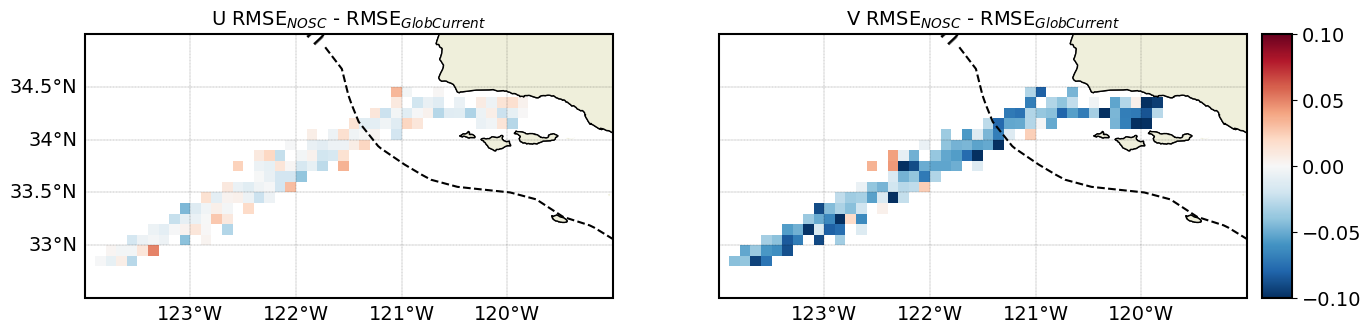

In [8]:
zoom=[-124,-119,32.5,35]

from scipy.stats import binned_statistic_2d
# Use binned_statistic_2d to compute the count (or mean) for each bin
means, lon_edges, lat_edges, binnumber = binned_statistic_2d(
    np.array(list_lon), np.array(list_lat), np.array(list_u_hfr_rmse)-np.array(list_u_gc_rmse), 'mean', bins=[lon_bins, lat_bins]
)
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
means = means.T


fig, axss = plt.subplots(nrows=1,ncols=2,
                subplot_kw={'projection': ccrs.PlateCarree()},
                figsize=(15*1, 8*1))

axs=axss[0]
title = 'U RMSE$_{NOSC}$ - RMSE$_{GlobCurrent}$'
plot_cm(means,lon,lat,cmap=plt.cm.RdBu_r,axs=axs,fig=fig,colorbar=False,zoom=zoom,vmin=-0.1,vmax=0.1,title=title)

label_positions = [(-121.5,35.8)]  # Example positions
level=[100]
contour = axs.contour(ds.lon,ds.lat,dist_grid,level,colors='k',linestyles=['--','--'])
# Label the contour
axs.clabel(contour,levels=level, inline=True, manual=label_positions, fontsize=20, fmt='%1.0fkm',colors='k')
#axs.legend(loc=2)

axs=axss[1]

means, lon_edges, lat_edges, binnumber = binned_statistic_2d(
    np.array(list_lon), np.array(list_lat), (np.array(list_v_hfr_rmse)-np.array(list_v_gc_rmse)), 'mean', bins=[lon_bins, lat_bins]
)
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
means = means.T

title = 'V RMSE$_{NOSC}$ - RMSE$_{GlobCurrent}$'
gl,pm = plot_cm(means,lon,lat,cmap=plt.cm.RdBu_r,axs=axs,fig=fig,colorbar=True,zoom=zoom,vmin=-0.1,vmax=0.1,title=title)
label_positions = [(-121.5,35.8)]  # Example positions
level=[100]
contour = axs.contour(ds.lon,ds.lat,dist_grid,level,colors='k',linestyles=['--','--'])

gl.left_labels = False

axs.clabel(contour,levels=level, inline=True, manual=label_positions, fontsize=20, fmt='%1.0fkm',colors='k')
#axs.legend(loc=2)

In [9]:
name_product = 'NOSC$_{duacs}$'
name_product_neu = 'NOSC$_{neurost}$'
name_glider = 'GliderL66'
fontsize = 14

list_time = gl_dmean.time.values
#list_lat = gl_dmean.lat.values
#list_lon = gl_dmean.lon.values

# Valeurs brutes interpolées (avant filtrage)
u_gc  = gc_pts.u_mean.values
v_gc  = gc_pts.v_mean.values
u_hfr = ds_pts.u_mean.values
v_hfr = ds_pts.v_mean.values
u_neu = ds_pts_neu.u_mean.values
v_neu = ds_pts_neu.v_mean.values

# Filter out NaN pairs (basé sur U, comme dans le code d'origine)
valid_indices = ~(np.isnan(u_gc) | np.isnan(u_hfr))

# Valeurs brutes (u_mean / u_15m etc.)
u_gc  = u_gc[valid_indices]
v_gc  = v_gc[valid_indices]
u_hfr = u_hfr[valid_indices]
v_hfr = v_hfr[valid_indices]
u_glf = u_gl[valid_indices]
v_glf = v_gl[valid_indices]
u_neu = u_neu[valid_indices]
v_neu = v_neu[valid_indices]



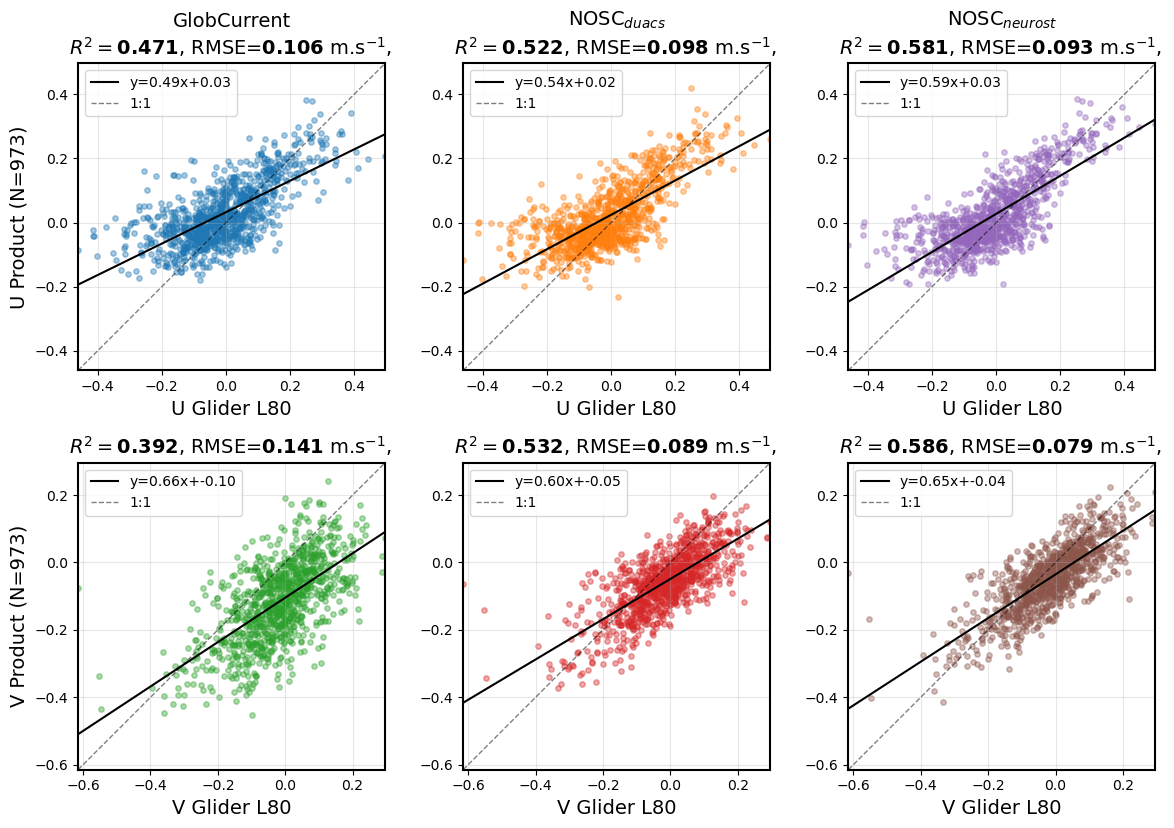

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def compute_stats(x, y):
    """Remove NaNs, compute linear regression stats."""
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    slope, intercept, r, p, se = stats.linregress(x, y)
    rmse = np.sqrt(np.mean((x - y) ** 2))
    return x, y, slope, intercept, r, rmse

# Pairs to compare: (obs, model, product_name, color)
comparisons = [
    (u_glf, u_gc,  'GlobCurrent',          'tab:blue'),
    (u_glf, u_hfr, name_product,  'tab:orange'),
    (u_glf, u_neu, name_product_neu,         'tab:purple'),
    (v_glf, v_gc,  'GlobCurrent',          'tab:green'),
    (v_glf, v_hfr, name_product,  'tab:red'),
    (v_glf, v_neu, name_product_neu,         'tab:brown'),
]

fig, axs = plt.subplots(2, 3, figsize=(15, 8.5))
axs = axs.flatten()

for i, (x, y, prod_name, color) in enumerate(comparisons):
    ax = axs[i]
    x_clean, y_clean, slope, intercept, r, rmse = compute_stats(x, y)

    # scatter
    ax.scatter(x_clean, y_clean, s=15, alpha=0.4, color=color)

    # regression line
    xfit = np.linspace(x_clean.min(), x_clean.max(), 100)
    yfit = slope * xfit + intercept
    ax.plot(xfit, yfit, color='k', linewidth=1.5,
            label=f'y={slope:.2f}x+{intercept:.2f}')

    # 1:1 reference line
    lims = [min(x_clean.min(), y_clean.min()), max(x_clean.max(), y_clean.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='1:1')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')

    # xlabel: U/V Glider selon la ligne
    comp = 'U' if i < 3 else 'V'
    ax.set_xlabel(f'{comp} Glider L80', fontsize=fontsize)

    # ylabel seulement sur la colonne de gauche
    if i % 3 == 0:
        ax.set_ylabel(f'{comp} Product (N={len(x_clean)})', fontsize=fontsize)

    # titre seulement pour la ligne du haut
    if i < 3:
        ax.set_title(
            f'{prod_name}\n'
            f'$R^2=\\mathbf{{{r**2:.3f}}}$, '
            f'RMSE=$\\mathbf{{{rmse:.3f}}}$' ' m.s$^{-1}$, ',
            fontsize=fontsize
        )
    else:
        ax.set_title(
            f'$R^2=\\mathbf{{{r**2:.3f}}}$, '
            f'RMSE=$\\mathbf{{{rmse:.3f}}}$' ' m.s$^{-1}$, ',
            fontsize=fontsize
        )

    ax.tick_params(axis='both', labelsize=10)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.subplots_adjust(wspace=-0.4, hspace=0.3)
plt.show()

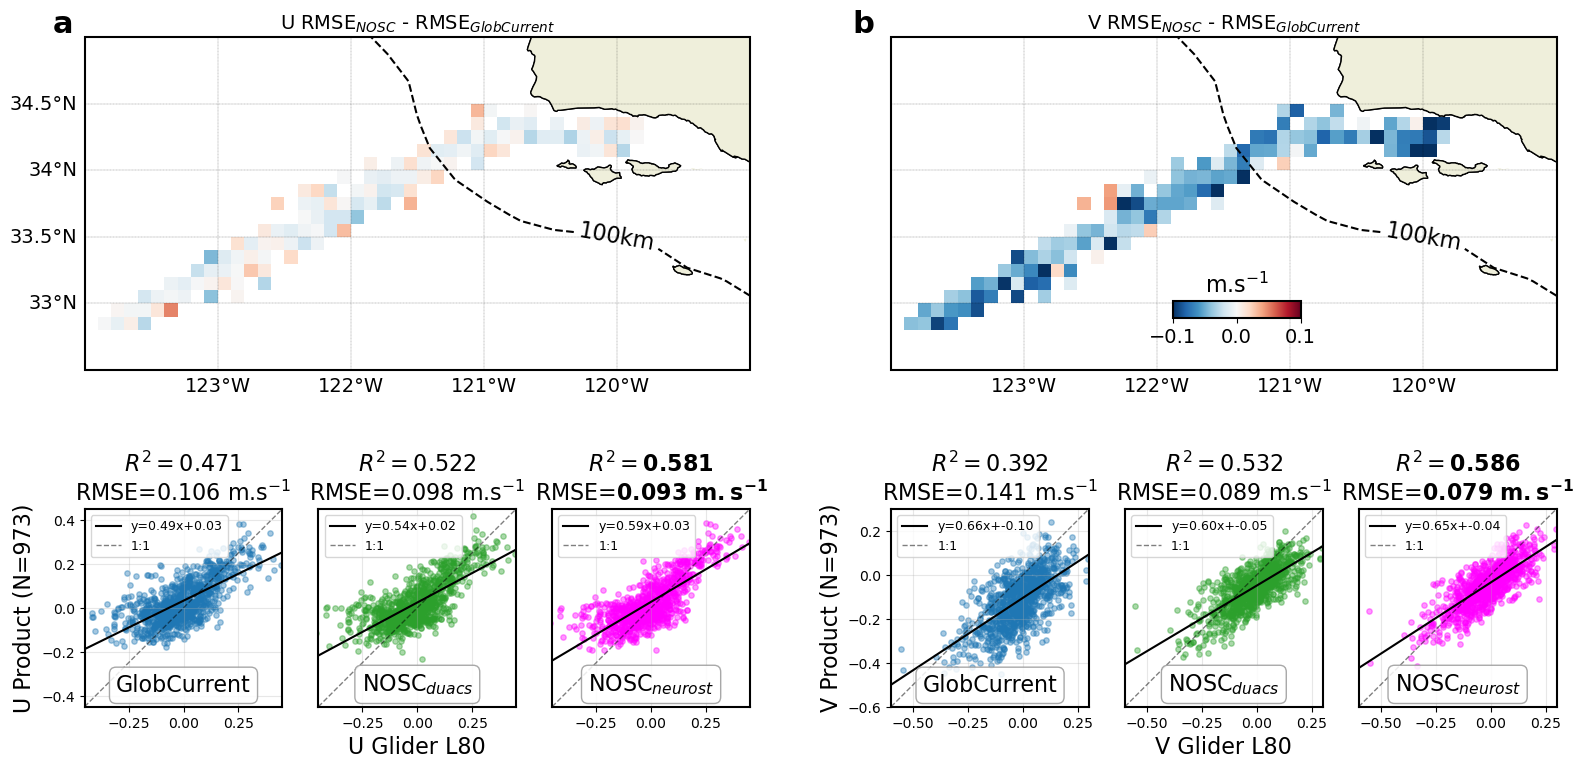

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import binned_statistic_2d
import cartopy.crs as ccrs

cmap='RdYlBu_r'
cmap='RdBu_r'
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.5

zoom=[-124,-119,32.5,35]
fontsize = 16

# =========================================================
# Figure globale : 7 colonnes -> U (0,1,2) | spacer (3) | V (4,5,6)
# =========================================================
fig = plt.figure(figsize=(16, 11))

gs = gridspec.GridSpec(
    2, 7,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1, 0.35, 1, 1, 1],  # colonne 3 = spacer étroit
    hspace=-0.38, wspace=0.20,
    left=0.05, right=0.97, top=0.98, bottom=0.02
)


# =========================================================
# PARTIE HAUTE : cartes U et V (fusionnées sur leurs 3 colonnes respectives)
# =========================================================
axs0 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
axs1 = fig.add_subplot(gs[0, 4:7], projection=ccrs.PlateCarree())

# --- Carte U ---
means, lon_edges, lat_edges, binnumber = binned_statistic_2d(
    np.array(list_lon), np.array(list_lat),
    np.array(list_u_hfr_rmse) - np.array(list_u_gc_rmse),
    'mean', bins=[lon_bins, lat_bins]
)
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
means = means.T

title = 'U RMSE$_{NOSC}$ - RMSE$_{GlobCurrent}$'
gl,pm = plot_cm(means, lon, lat, cmap=cmap, axs=axs0, fig=fig,
        colorbar=False, zoom=zoom, vmin=-0.1, vmax=0.1, title=title)

label_positions = [(-120, 33.5)]
level = [100]
contour = axs0.contour(ds.lon, ds.lat, dist_grid, level, colors='k', linestyles=['--', '--'])
axs0.clabel(contour, levels=level, inline=True, manual=label_positions, fontsize=16, fmt='%1.0fkm', colors='k')

# --- Colorbar horizontale, placée dans la colonne spacer, associée à la carte U ---
#cax = fig.add_axes([0.47, 0.46, 0.08, 0.015])
cax = fig.add_axes([0.73, 0.58, 0.08, 0.015])
cbar = fig.colorbar(pm, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_title('m.s$^{-1}$', fontsize=fontsize)

#cax = fig.add_axes([0.49, 0.55, 0.015, 0.3])
#cbar = fig.colorbar(pm, cax=cax, orientation='vertical')
#cbar.ax.tick_params(labelsize=14)
#cbar.ax.set_title('m.s$^{-1}$', fontsize=fontsize)

# Garder seulement 3 ticks : -0.1, 0, 0.1
cbar.set_ticks([-0.1, 0, 0.1])

# --- Carte V ---
means, lon_edges, lat_edges, binnumber = binned_statistic_2d(
    np.array(list_lon), np.array(list_lat),
    np.array(list_v_hfr_rmse) - np.array(list_v_gc_rmse),
    'mean', bins=[lon_bins, lat_bins]
)
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
means = means.T

title = 'V RMSE$_{NOSC}$ - RMSE$_{GlobCurrent}$'
gl,pm = plot_cm(means, lon, lat, cmap=cmap, axs=axs1, fig=fig,
             colorbar=False, zoom=zoom, vmin=-0.1, vmax=0.1, title=title) #colorbar_title='[m.s$^{-1}$]'

contour = axs1.contour(ds.lon, ds.lat, dist_grid, level, colors='k', linestyles=['--', '--'])
gl.left_labels = False
axs1.clabel(contour, levels=level, inline=True, manual=label_positions, fontsize=16, fmt='%1.0fkm', colors='k')

# =========================================================
# PARTIE BASSE : régressions U (cols 0,1,2) et V (cols 4,5,6)
# =========================================================
def compute_stats(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    slope, intercept, r, p, se = stats.linregress(x, y)
    rmse = np.sqrt(np.mean((x - y) ** 2))
    return x, y, slope, intercept, r, rmse

comparisons_u = [
    (u_glf, u_gc,  'GlobCurrent',    'tab:blue'),
    (u_glf, u_hfr, name_product,     'tab:green'),
    (u_glf, u_neu, name_product_neu, 'magenta'),
]

comparisons_v = [
    (v_glf, v_gc,  'GlobCurrent',    'tab:blue'),
    (v_glf, v_hfr, name_product,     'tab:green'),
    (v_glf, v_neu, name_product_neu, 'magenta'),
]

def plot_regression(ax, x, y, prod_name, color, comp_label, show_ylabel, show_xlabel, lims=None, bold=False):
    x_clean, y_clean, slope, intercept, r, rmse = compute_stats(x, y)

    if lims is None:
        lims = [min(x_clean.min(), y_clean.min()), max(x_clean.max(), y_clean.max())]
        
    ax.scatter(x_clean, y_clean, s=15, alpha=0.4, color=color)

    xfit = np.linspace(lims[0], lims[1], 100)
    yfit = slope * xfit + intercept
    ax.plot(xfit, yfit, color='k', linewidth=1.5,
            label=f'y={slope:.2f}x+{intercept:.2f}')


    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='1:1')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')

    if show_xlabel:
        ax.set_xlabel(f'{comp_label} Glider L80', fontsize=fontsize)

    if show_ylabel:
        ax.set_ylabel(f'{comp_label} Product (N={len(x_clean)})', fontsize=fontsize)
    else:
        ax.set_yticks([])

    # Titre : bold uniquement si bold=True
    if bold:
        title_str = (
            f'$R^2=\\mathbf{{{r**2:.3f}}}$\n'
            f'RMSE=$\\mathbf{{{rmse:.3f}}}$' ' $\\mathbf{m.s^{-1}}$'
        )
    else:
        title_str = (
            f'$R^2={r**2:.3f}$\n'
            f'RMSE=${rmse:.3f}$' ' m.s$^{-1}$'
        )
    ax.set_title(title_str, fontsize=fontsize)

    # Nom du produit dans une boîte de texte, en bas au centre du plot
    ax.text(
        0.5, 0.05, prod_name,
        transform=ax.transAxes,
        fontsize=fontsize, ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='0.6', alpha=0.85)
    )

    ax.tick_params(axis='both', labelsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)

# --- Ligne U (cols 0,1,2) : ylabel + xlabel seulement sur le 2e plot (col == 1) ---
for col, (x, y, prod_name, color) in enumerate(comparisons_u):
    ax = fig.add_subplot(gs[1, col])
    lims = [-0.45, 0.45]
    plot_regression(ax, x, y, prod_name, color, comp_label='U',
                     show_ylabel=(col == 0), show_xlabel=(col == 1), lims=lims,
                     bold=(col == 2))

# --- Ligne V (cols 4,5,6) : ylabel + xlabel seulement sur le 2e plot (col == 1) ---
for col, (x, y, prod_name, color) in enumerate(comparisons_v):
    ax = fig.add_subplot(gs[1, 4 + col])
    lims = [-0.6, 0.3]
    plot_regression(ax, x, y, prod_name, color, comp_label='V',
                     show_ylabel=(col == 0), show_xlabel=(col == 1), lims=lims,
                     bold=(col == 2))
# =========================================================
# Labels de panneau 'a' (bloc U) et 'b' (bloc V)
# =========================================================
fig.text(0.03, 0.86, 'a', fontsize=22, fontweight='bold', ha='left', va='top')
fig.text(0.53, 0.86, 'b', fontsize=22, fontweight='bold', ha='left', va='top')

fig.tight_layout()
plt.savefig('score_glider80.png',dpi=300)

plt.show()

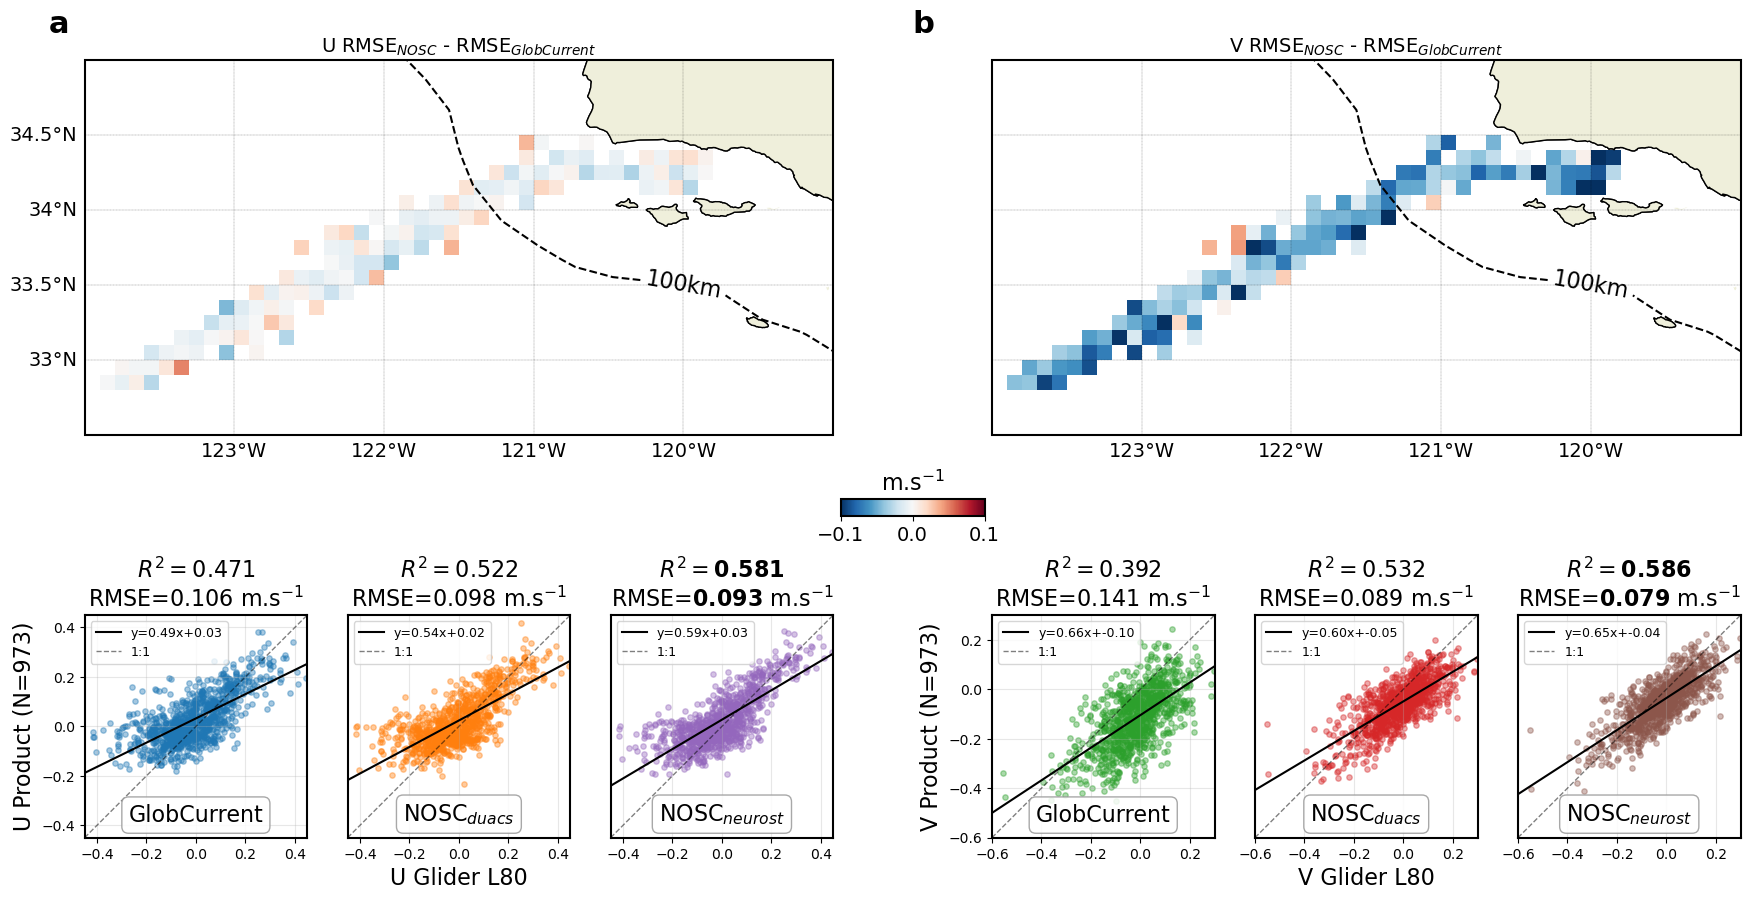

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import binned_statistic_2d
import cartopy.crs as ccrs

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.5

zoom=[-124,-119,32.5,35]
fontsize = 16

# =========================================================
# Figure globale : 7 colonnes -> U (0,1,2) | spacer (3) | V (4,5,6)
# =========================================================
fig = plt.figure(figsize=(18, 11))

gs = gridspec.GridSpec(
    2, 7,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1, 1, 0.35, 1, 1, 1],  # colonne 3 = spacer étroit
    hspace=0.05, wspace=0.20,
    left=0.05, right=0.97, top=0.93, bottom=0.08
)

# =========================================================
# PARTIE HAUTE : cartes U et V (fusionnées sur leurs 3 colonnes respectives)
# =========================================================
axs0 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
axs1 = fig.add_subplot(gs[0, 4:7], projection=ccrs.PlateCarree())

# --- Carte U ---
means, lon_edges, lat_edges, binnumber = binned_statistic_2d(
    np.array(list_lon), np.array(list_lat),
    np.array(list_u_hfr_rmse) - np.array(list_u_gc_rmse),
    'mean', bins=[lon_bins, lat_bins]
)
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
means = means.T

title = 'U RMSE$_{NOSC}$ - RMSE$_{GlobCurrent}$'
gl,pm = plot_cm(means, lon, lat, cmap=plt.cm.RdBu_r, axs=axs0, fig=fig,
        colorbar=False, zoom=zoom, vmin=-0.1, vmax=0.1, title=title)

label_positions = [(-120, 33.5)]
level = [100]
contour = axs0.contour(ds.lon, ds.lat, dist_grid, level, colors='k', linestyles=['--', '--'])
axs0.clabel(contour, levels=level, inline=True, manual=label_positions, fontsize=16, fmt='%1.0fkm', colors='k')

# --- Colorbar horizontale, placée dans la colonne spacer, associée à la carte U ---
cax = fig.add_axes([0.47, 0.46, 0.08, 0.015])
cbar = fig.colorbar(pm, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_title('m.s$^{-1}$', fontsize=fontsize)

#cax = fig.add_axes([0.49, 0.55, 0.015, 0.3])
#cbar = fig.colorbar(pm, cax=cax, orientation='vertical')
#cbar.ax.tick_params(labelsize=14)
#cbar.ax.set_title('m.s$^{-1}$', fontsize=fontsize)

# Garder seulement 3 ticks : -0.1, 0, 0.1
cbar.set_ticks([-0.1, 0, 0.1])

# --- Carte V ---
means, lon_edges, lat_edges, binnumber = binned_statistic_2d(
    np.array(list_lon), np.array(list_lat),
    np.array(list_v_hfr_rmse) - np.array(list_v_gc_rmse),
    'mean', bins=[lon_bins, lat_bins]
)
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
means = means.T

title = 'V RMSE$_{NOSC}$ - RMSE$_{GlobCurrent}$'
gl,pm = plot_cm(means, lon, lat, cmap=plt.cm.RdBu_r, axs=axs1, fig=fig,
             colorbar=False, zoom=zoom, vmin=-0.1, vmax=0.1, title=title) #colorbar_title='[m.s$^{-1}$]'

contour = axs1.contour(ds.lon, ds.lat, dist_grid, level, colors='k', linestyles=['--', '--'])
gl.left_labels = False
axs1.clabel(contour, levels=level, inline=True, manual=label_positions, fontsize=16, fmt='%1.0fkm', colors='k')

# =========================================================
# PARTIE BASSE : régressions U (cols 0,1,2) et V (cols 4,5,6)
# =========================================================
def compute_stats(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    slope, intercept, r, p, se = stats.linregress(x, y)
    rmse = np.sqrt(np.mean((x - y) ** 2))
    return x, y, slope, intercept, r, rmse

comparisons_u = [
    (u_glf, u_gc,  'GlobCurrent',    'tab:blue'),
    (u_glf, u_hfr, name_product,     'tab:orange'),
    (u_glf, u_neu, name_product_neu, 'tab:purple'),
]

comparisons_v = [
    (v_glf, v_gc,  'GlobCurrent',    'tab:green'),
    (v_glf, v_hfr, name_product,     'tab:red'),
    (v_glf, v_neu, name_product_neu, 'tab:brown'),
]

def plot_regression(ax, x, y, prod_name, color, comp_label, show_ylabel, show_xlabel, lims=None, bold=False):
    x_clean, y_clean, slope, intercept, r, rmse = compute_stats(x, y)

    ax.scatter(x_clean, y_clean, s=15, alpha=0.4, color=color)

    xfit = np.linspace(x_clean.min(), x_clean.max(), 100)
    yfit = slope * xfit + intercept
    ax.plot(xfit, yfit, color='k', linewidth=1.5,
            label=f'y={slope:.2f}x+{intercept:.2f}')

    if lims is None:
        lims = [min(x_clean.min(), y_clean.min()), max(x_clean.max(), y_clean.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='1:1')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')

    if show_xlabel:
        ax.set_xlabel(f'{comp_label} Glider L80', fontsize=fontsize)

    if show_ylabel:
        ax.set_ylabel(f'{comp_label} Product (N={len(x_clean)})', fontsize=fontsize)
    else:
        ax.set_yticks([])

    # Titre : bold uniquement si bold=True
    if bold:
        title_str = (
            f'$R^2=\\mathbf{{{r**2:.3f}}}$\n'
            f'RMSE=$\\mathbf{{{rmse:.3f}}}$' ' m.s$^{-1}$'
        )
    else:
        title_str = (
            f'$R^2={r**2:.3f}$\n'
            f'RMSE=${rmse:.3f}$' ' m.s$^{-1}$'
        )
    ax.set_title(title_str, fontsize=fontsize)

    # Nom du produit dans une boîte de texte, en bas au centre du plot
    ax.text(
        0.5, 0.05, prod_name,
        transform=ax.transAxes,
        fontsize=fontsize, ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='0.6', alpha=0.85)
    )

    ax.tick_params(axis='both', labelsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)

# --- Ligne U (cols 0,1,2) : ylabel + xlabel seulement sur le 2e plot (col == 1) ---
for col, (x, y, prod_name, color) in enumerate(comparisons_u):
    ax = fig.add_subplot(gs[1, col])
    lims = [-0.45, 0.45]
    plot_regression(ax, x, y, prod_name, color, comp_label='U',
                     show_ylabel=(col == 0), show_xlabel=(col == 1), lims=lims,
                     bold=(col == 2))

# --- Ligne V (cols 4,5,6) : ylabel + xlabel seulement sur le 2e plot (col == 1) ---
for col, (x, y, prod_name, color) in enumerate(comparisons_v):
    ax = fig.add_subplot(gs[1, 4 + col])
    lims = [-0.6, 0.3]
    plot_regression(ax, x, y, prod_name, color, comp_label='V',
                     show_ylabel=(col == 0), show_xlabel=(col == 1), lims=lims,
                     bold=(col == 2))
# =========================================================
# Labels de panneau 'a' (bloc U) et 'b' (bloc V)
# =========================================================
fig.text(0.03, 0.92, 'a', fontsize=22, fontweight='bold', ha='left', va='top')
fig.text(0.51, 0.92, 'b', fontsize=22, fontweight='bold', ha='left', va='top')

fig.tight_layout()
plt.savefig('score_glider80.png',dpi=300)

plt.show()
